In [ ]:
import pandas as pd
import psycopg2
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

conn = psycopg2.connect(
    dbname='postgres',
    user='postgres',
    host='localhost',
    password=input()
)

cur = conn.cursor

query = """SELECT t.issuer_id || ' - ' || t3.issuer_name AS Issuer_Title,
        SUM(CASE WHEN t2.months_delinquent <> 0 THEN 1 ELSE 0 END) AS Total_Delinquencies,
        t3.citystate AS Location,
        ROUND(SUM(CASE WHEN t.first_time_home_buyer = 'Y' THEN 1 ELSE 0 END)::NUMERIC/COUNT(*),2)  AS Percent_FTHB,
        ROUND(SUM(CASE WHEN t.down_payment_assistance = 'Y' THEN 1 ELSE 0 END)::NUMERIC/COUNT(*),2)  AS Percent_dpa,
        CASE WHEN t3.subservicer <> 'No Subservicer' THEN t4.subservicer_name ELSE 'No Subservicer' END AS Subservicer
        FROM
        gnma_static_table t
        JOIN mbs_loans_monthly t2 ON t2.disclosure_sequence_number = t.disclosure_sequence_number
        JOIN issuer_info t3 ON t3.issuer_number = t2.issuer_id
        LEFT JOIN subservicers t4 ON t4.subservicer_id = t3.subservicer
        WHERE t3.issuer_group = 'Mega'
        GROUP BY t.issuer_id || ' - ' || t3.issuer_name, t3.citystate, CASE WHEN t3.subservicer <> 'No Subservicer' THEN t4.subservicer_name ELSE 'No Subservicer' END"""

df = pd.read_sql(query, conn)

conn.close()

print(df.head())

C:\Users\H59045\AppData\Local\Temp\1\ipykernel_12024\4038227966.py:28: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


                               issuer_title  total_delinquencies  \
0  3871 - Freedom Home Mortgage Corporation               177997   
1               4042 - Rocket Mortgage, LLC               134840   
2        4094 - PennyMac Loan Services, LLC               122472   
3           4135 - Planet Home Lending, LLC                50154   
4  4143 - Carrington Mortgage Services, LLC               103426   

         location  percent_fthb  percent_dpa     subservicer  
0  FL, Boca Raton          0.37         0.05  No Subservicer  
1     MI, Detroit          0.30         0.06  No Subservicer  
2    CA, Moonpark          0.49         0.03  No Subservicer  
3     CT, Meriden          0.45         0.02  No Subservicer  
4      CA, Orange          0.36         0.08  No Subservicer  


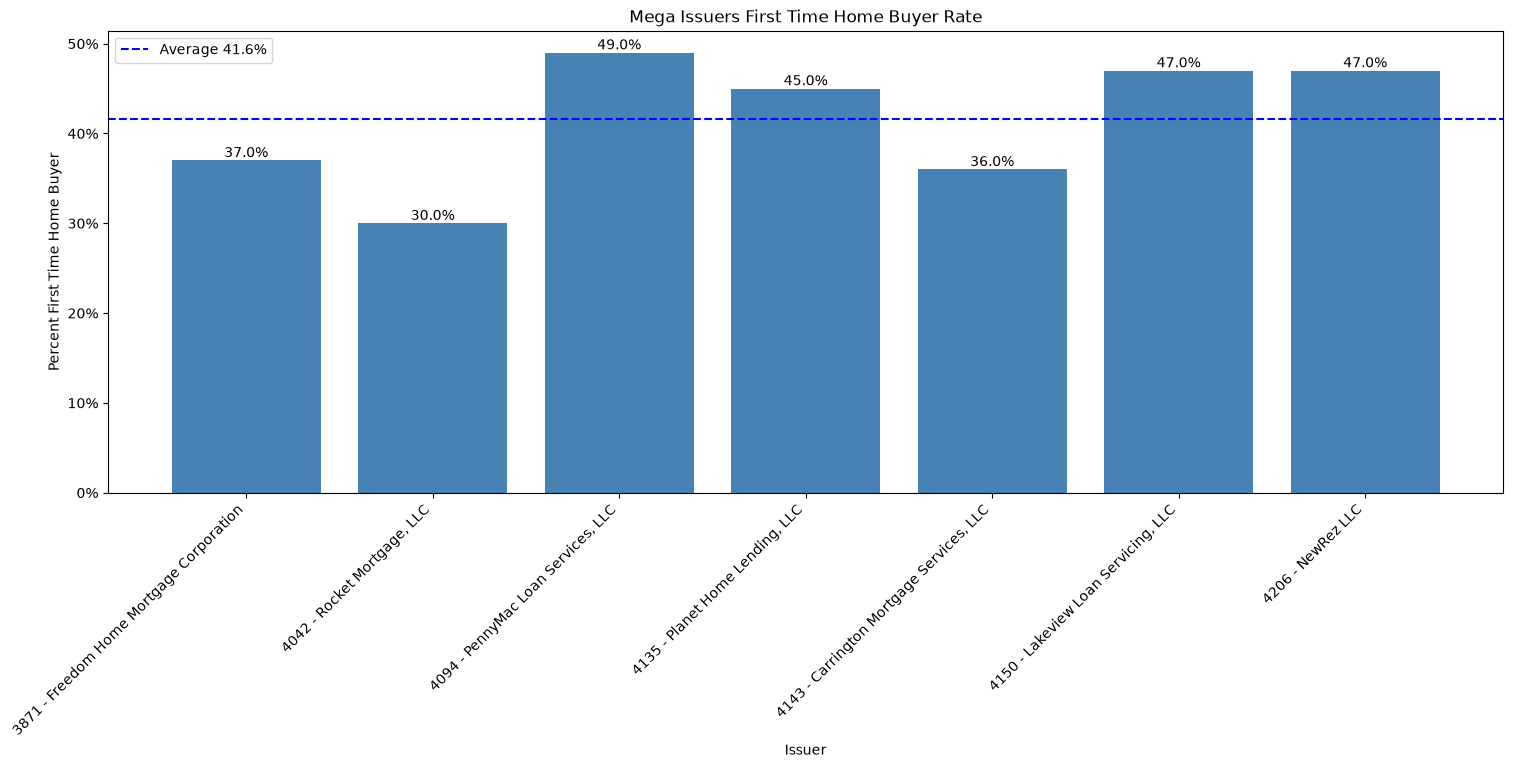

In [8]:
plt.figure(figsize=(18,6))
bars = plt.bar(df['issuer_title'], df['percent_fthb'], color='steelblue',)
plt.bar_label(bars,fmt=lambda x: f'{x*100:.1f}%')
avg = df['percent_fthb'].mean()
plt.axhline(avg, color='blue', linestyle='--', linewidth=1.5,label=f'Average {avg*100:.1f}%')
plt.title('Mega Issuers First Time Home Buyer Rate')
plt.xlabel('Issuer')
plt.ylabel('Percent First Time Home Buyer')
plt.xticks(rotation=45, ha='right')
plt.gca().yaxis.set_major_formatter(PercentFormatter(1.0))
plt.legend()

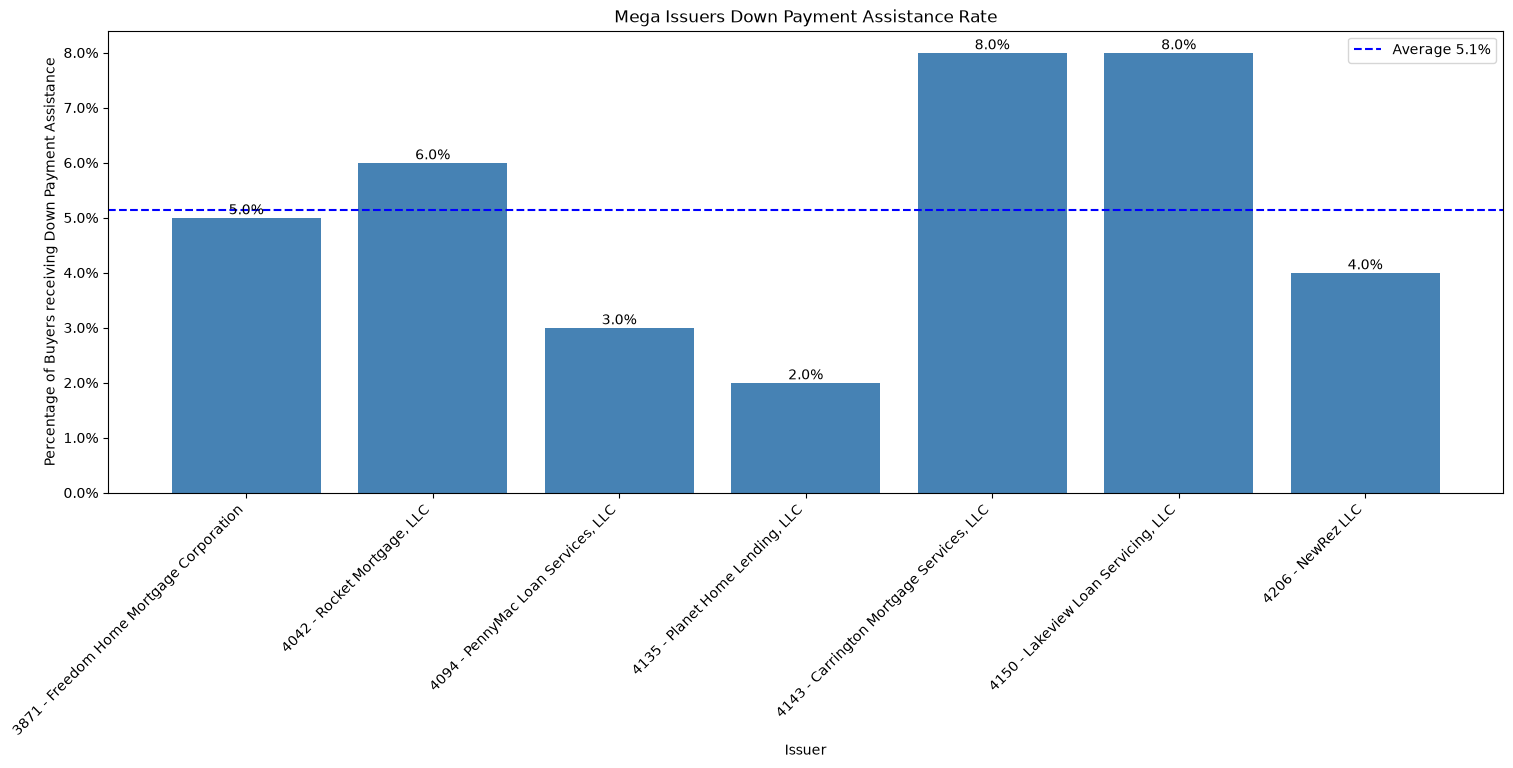

In [11]:
plt.figure(figsize=(18,6))
bars = plt.bar(df['issuer_title'], df['percent_dpa'], color='steelblue',)
plt.bar_label(bars,fmt=lambda x: f'{x*100:.1f}%')
avg = df['percent_dpa'].mean()
plt.axhline(avg, color='blue', linestyle='--', linewidth=1.5,label=f'Average {avg*100:.1f}%')
plt.title('Mega Issuers Down Payment Assistance Rate')
plt.xlabel('Issuer')
plt.ylabel('Percentage of Buyers receiving Down Payment Assistance')
plt.xticks(rotation=45, ha='right')
plt.gca().yaxis.set_major_formatter(PercentFormatter(1.0))
plt.legend()

In [10]:
from matplotlib.ticker import PercentFormatter